# Experimento 3 — Data Augmentation
## Comparação: sem aug vs aug-light vs aug-medium vs aug-strong
### Por que augmentation pode resolver o gap val→test
### Design experimental

## 1. Setup

In [1]:
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
import matplotlib.pyplot as plt

SEED = 42

def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_all_seeds()
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Path("checkpoints").mkdir(exist_ok=True)
Path("figs").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

Device: cuda
GPU: NVIDIA RTX A6000


In [ ]:
from src.gtsrb import (
    get_dataloaders,
    save_predictions,
    NUM_CLASSES,
    GTSRB_CLASSES,
)

MEAN = [0.3403, 0.3121, 0.3214]
STD  = [0.2724, 0.2608, 0.2669]

print(f"NUM_CLASSES = {NUM_CLASSES}")

NUM_CLASSES = 43


## 2. Definição dos pipelines de augmentation

In [ ]:
IMG_SIZE = 32

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

sem_aug = eval_transform

aug_light = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

aug_medium = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
    ),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

aug_strong = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
    ),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))],
        p=0.3,
    ),
    transforms.Normalize(mean=MEAN, std=STD),
])

AUG_PIPELINES = {
    "sem_aug":    sem_aug,
    "aug_light":  aug_light,
    "aug_medium": aug_medium,
    "aug_strong": aug_strong,
}

for name in AUG_PIPELINES:
    print(f"  {name}: definido")

  sem_aug: definido
  aug_light: definido
  aug_medium: definido
  aug_strong: definido


## 3. Sanity check visual

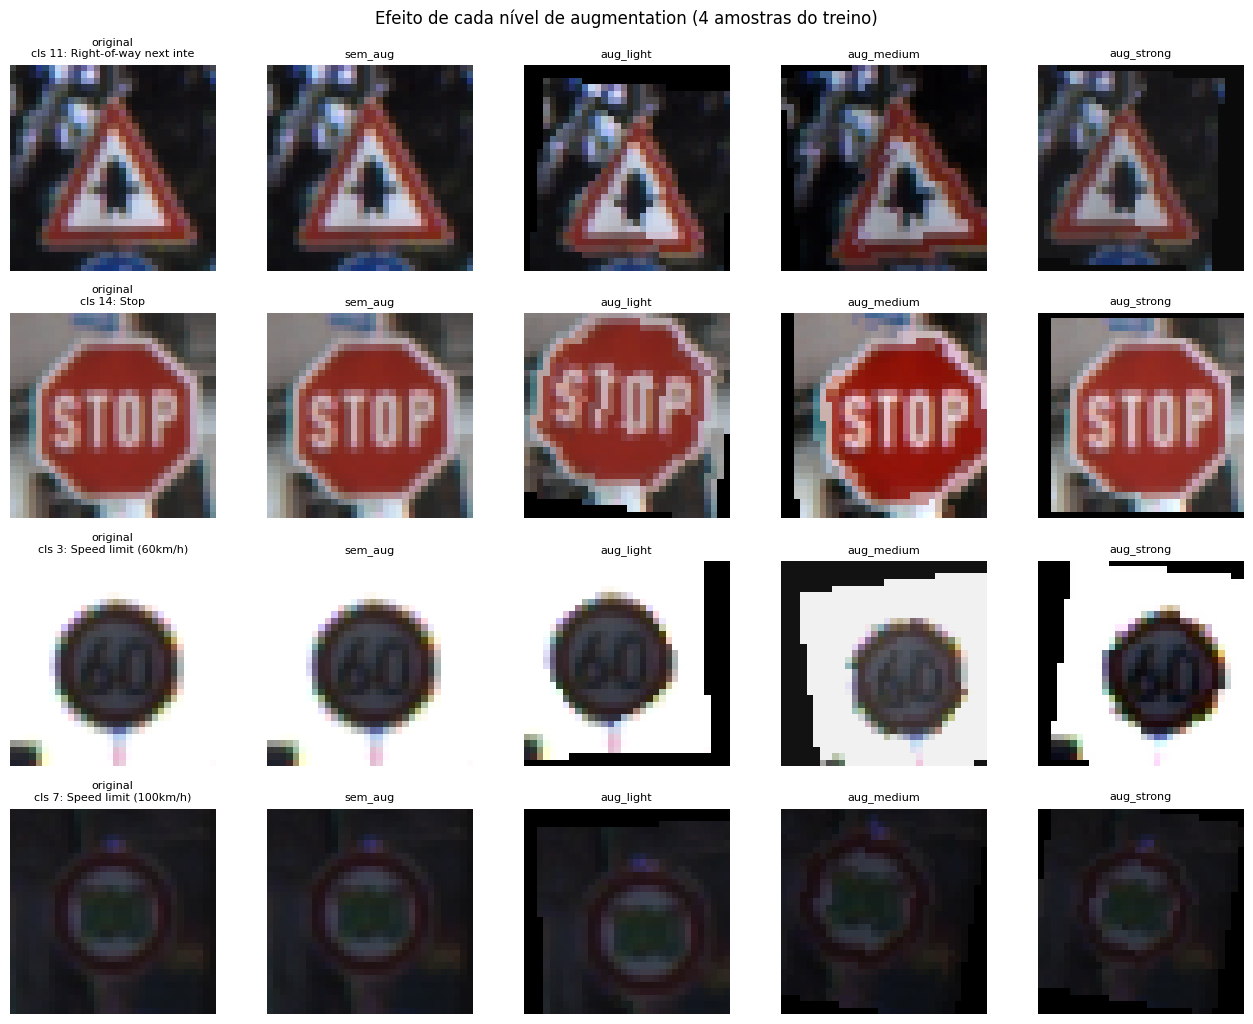

In [ ]:
def denorm(t):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

loader_plain, _, _ = get_dataloaders(
    img_size=IMG_SIZE, batch_size=128, train_transform=sem_aug, num_workers=0,
)
imgs, lbls = next(iter(loader_plain))
sample_idx = [0, 5, 12, 23] 

fig, axes = plt.subplots(len(sample_idx), 5, figsize=(13, 2.6 * len(sample_idx)))

plain_resize = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

from torchvision.datasets import GTSRB
raw_dataset = GTSRB(root="./data", split="train", download=False)
subset = loader_plain.dataset
raw_indices = [subset.indices[i] for i in sample_idx]

for row, (s_idx, raw_idx) in enumerate(zip(sample_idx, raw_indices)):
    pil_img, label = raw_dataset[raw_idx]
    axes[row, 0].imshow(plain_resize(pil_img).permute(1, 2, 0).numpy())
    axes[row, 0].set_title(f"original\ncls {label}: {GTSRB_CLASSES[label][:22]}", fontsize=8)
    axes[row, 0].axis("off")

    for col, (aug_name, aug_t) in enumerate(AUG_PIPELINES.items(), start=1):
        torch.manual_seed(SEED + row * 100 + col)
        t = aug_t(pil_img)
        axes[row, col].imshow(denorm(t))
        axes[row, col].set_title(aug_name, fontsize=8)
        axes[row, col].axis("off")

plt.suptitle("Efeito de cada nível de augmentation (4 amostras do treino)")
plt.tight_layout()
plt.savefig("figs/exp3_aug_examples.png", dpi=150, bbox_inches="tight")
plt.show()

del loader_plain

## 4. Modelo — BN-conv+fc (vencedor do Exp 2)

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=43, img_size=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        spatial = img_size // 4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * spatial * spatial, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def build_model():
    set_all_seeds(SEED)
    return CNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(DEVICE)

m = build_model()
n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"Modelo: BN-conv+fc | params={n_params:,}")
del m

Modelo: BN-conv+fc | params=1,079,979


## 5. Funções de treino e avaliação

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()
    ys, ps = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        preds = model(images).argmax(1).cpu().numpy()
        ps.append(preds)
        ys.append(labels.numpy())
    return np.concatenate(ys), np.concatenate(ps)

def per_class_accuracy(y_true, y_pred, num_classes):
    accs = np.zeros(num_classes)
    counts = np.zeros(num_classes, dtype=int)
    for c in range(num_classes):
        mask = y_true == c
        counts[c] = mask.sum()
        accs[c] = (y_pred[mask] == c).mean() if counts[c] > 0 else 0.0
    return accs, counts

## 6. Função de experimento (uma rodada completa)

In [ ]:
NUM_EPOCHS = 30
BATCH_SIZE = 128
NUM_WORKERS = 0 

def run_experiment(tag, train_transform):
    print(f"\n{'=' * 70}")
    print(f"  Treinando: {tag}")
    print(f"{'=' * 70}")

    train_loader, val_loader, test_loader = get_dataloaders(
        img_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        train_transform=train_transform,
        num_workers=NUM_WORKERS,
    )

    model = build_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    print(f"  Optimizer: SGD lr=0.01 momentum=0.9 | aug: {tag}")
    print(f"  Train batches: {len(train_loader)}")

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_epoch = 0.0, 0
    ckpt_path = f"checkpoints/exp3_{tag}_best.pt"

    t0 = time.time()
    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        flag = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            torch.save(model.state_dict(), ckpt_path)
            flag = "  <-- melhor val_acc"

        print(f"  Epoch {epoch:02d}/{NUM_EPOCHS} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f}{flag}")
    elapsed = time.time() - t0
    print(f"\n  Tempo: {elapsed:.1f}s | Melhor val_acc: {best_val_acc:.4f} (ep {best_epoch})")

    return {
        "tag": tag,
        "history": history,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "elapsed_sec": elapsed,
        "ckpt_path": ckpt_path,
        "test_loader": test_loader,  
    }

## 7. Rodadas (4 × 30 épocas)

In [8]:
all_results = {}
for tag, t in AUG_PIPELINES.items():
    all_results[tag] = run_experiment(tag, t)


  Treinando: sem_aug
  Optimizer: SGD lr=0.01 momentum=0.9 | aug: sem_aug
  Train batches: 167
  Epoch 01/30 | train_loss=1.0862 acc=0.7636 | val_loss=0.2703 acc=0.9638  <-- melhor val_acc
  Epoch 02/30 | train_loss=0.1447 acc=0.9852 | val_loss=0.1100 acc=0.9799  <-- melhor val_acc
  Epoch 03/30 | train_loss=0.0599 acc=0.9954 | val_loss=0.0621 acc=0.9917  <-- melhor val_acc
  Epoch 04/30 | train_loss=0.0317 acc=0.9984 | val_loss=0.0542 acc=0.9914
  Epoch 05/30 | train_loss=0.0206 acc=0.9992 | val_loss=0.0371 acc=0.9964  <-- melhor val_acc
  Epoch 06/30 | train_loss=0.0142 acc=0.9995 | val_loss=0.0471 acc=0.9893
  Epoch 07/30 | train_loss=0.0110 acc=0.9997 | val_loss=0.0267 acc=0.9961
  Epoch 08/30 | train_loss=0.0093 acc=0.9998 | val_loss=0.0274 acc=0.9962
  Epoch 09/30 | train_loss=0.0069 acc=0.9999 | val_loss=0.0203 acc=0.9974  <-- melhor val_acc
  Epoch 10/30 | train_loss=0.0056 acc=1.0000 | val_loss=0.0197 acc=0.9968
  Epoch 11/30 | train_loss=0.0050 acc=0.9999 | val_loss=0.0191 a

In [ ]:
summary = {}
for tag, r in all_results.items():
    summary[tag] = {k: v for k, v in r.items() if k not in ("ckpt_path", "test_loader")}
with open("checkpoints/exp3_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=float)
print("Resumo salvo em checkpoints/exp3_summary.json")

Resumo salvo em checkpoints/exp3_summary.json


## 8. Curvas de treino — 4 níveis sobrepostos

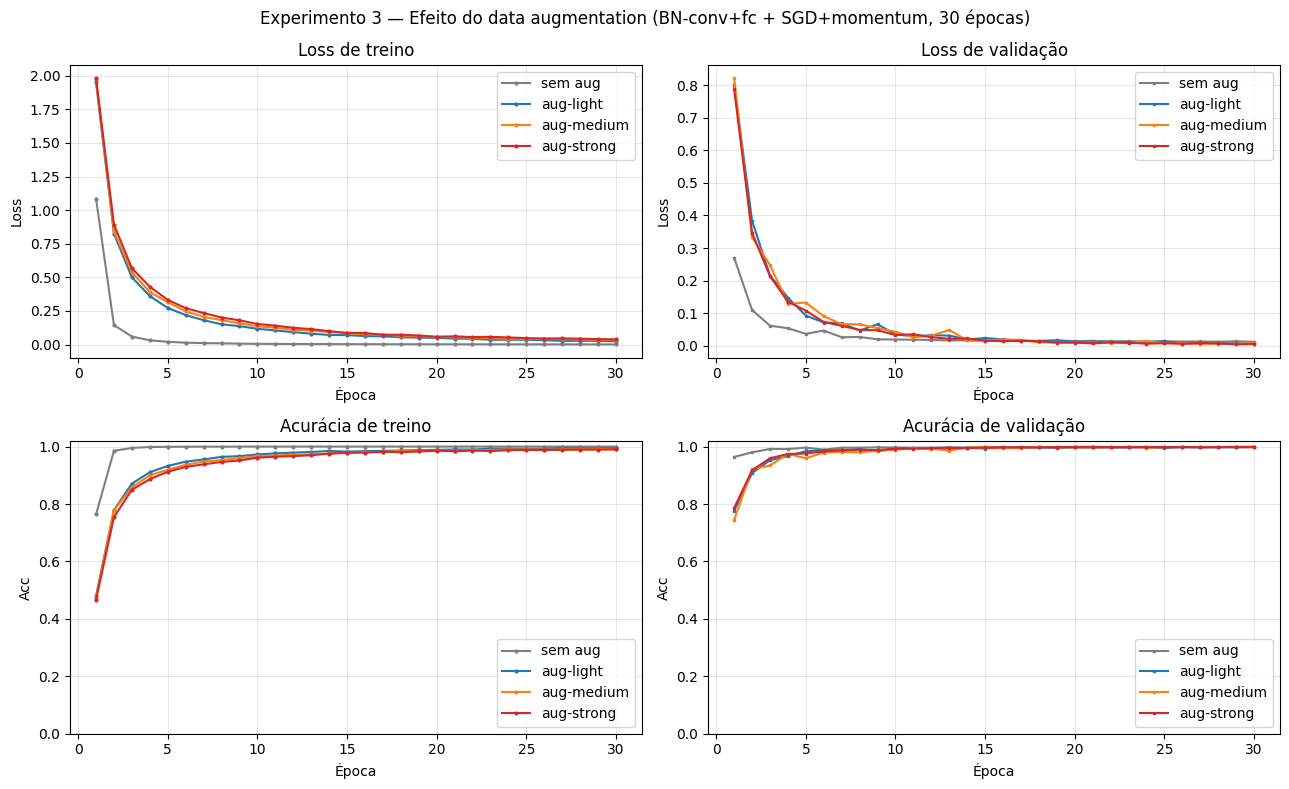

In [10]:
AUG_COLORS = {
    "sem_aug":    "tab:gray",
    "aug_light":  "tab:blue",
    "aug_medium": "tab:orange",
    "aug_strong": "tab:red",
}
AUG_LABELS = {
    "sem_aug":    "sem aug",
    "aug_light":  "aug-light",
    "aug_medium": "aug-medium",
    "aug_strong": "aug-strong",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
epochs = range(1, NUM_EPOCHS + 1)

for tag, r in all_results.items():
    axes[0, 0].plot(epochs, r["history"]["train_loss"], "o-", color=AUG_COLORS[tag], label=AUG_LABELS[tag], markersize=2)
axes[0, 0].set_title("Loss de treino"); axes[0, 0].set_xlabel("Época"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

for tag, r in all_results.items():
    axes[0, 1].plot(epochs, r["history"]["val_loss"], "s-", color=AUG_COLORS[tag], label=AUG_LABELS[tag], markersize=2)
axes[0, 1].set_title("Loss de validação"); axes[0, 1].set_xlabel("Época"); axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

for tag, r in all_results.items():
    axes[1, 0].plot(epochs, r["history"]["train_acc"], "o-", color=AUG_COLORS[tag], label=AUG_LABELS[tag], markersize=2)
axes[1, 0].set_title("Acurácia de treino"); axes[1, 0].set_xlabel("Época"); axes[1, 0].set_ylabel("Acc")
axes[1, 0].legend(loc="lower right"); axes[1, 0].grid(alpha=0.3); axes[1, 0].set_ylim(0, 1.02)

for tag, r in all_results.items():
    axes[1, 1].plot(epochs, r["history"]["val_acc"], "s-", color=AUG_COLORS[tag], label=AUG_LABELS[tag], markersize=2)
axes[1, 1].set_title("Acurácia de validação"); axes[1, 1].set_xlabel("Época"); axes[1, 1].set_ylabel("Acc")
axes[1, 1].legend(loc="lower right"); axes[1, 1].grid(alpha=0.3); axes[1, 1].set_ylim(0, 1.02)

plt.suptitle("Experimento 3 — Efeito do data augmentation (BN-conv+fc + SGD+momentum, 30 épocas)")
plt.tight_layout()
plt.savefig("figs/exp3_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.1 Gap train–val

In [11]:
print(f"  {'Configuração':<14s} | {'train final':>12s} | {'val final':>10s} | {'gap':>9s}")
print("-" * 60)
for tag, r in all_results.items():
    t_final = r["history"]["train_acc"][-1]
    v_final = r["history"]["val_acc"][-1]
    print(f"  {AUG_LABELS[tag]:<14s} | {t_final:>12.4f} | {v_final:>10.4f} | {t_final - v_final:>+9.4f}")

  Configuração   |  train final |  val final |       gap
------------------------------------------------------------
  sem aug        |       1.0000 |     0.9976 |   +0.0024
  aug-light      |       0.9945 |     0.9989 |   -0.0044
  aug-medium     |       0.9911 |     0.9977 |   -0.0067
  aug-strong     |       0.9901 |     0.9989 |   -0.0087


### 9.2 Estabilidade do treino (std nas últimas 5 épocas)

In [12]:
print(f"  {'Configuração':<14s} | {'val_acc final':>13s} | {'std últ 5':>10s}")
print("-" * 55)
for tag, r in all_results.items():
    last5 = r["history"]["val_acc"][-5:]
    print(f"  {AUG_LABELS[tag]:<14s} | {last5[-1]:>13.4f} | {float(np.std(last5)):>10.4f}")

  Configuração   | val_acc final |  std últ 5
-------------------------------------------------------
  sem aug        |        0.9976 |     0.0003
  aug-light      |        0.9989 |     0.0003
  aug-medium     |        0.9977 |     0.0004
  aug-strong     |        0.9989 |     0.0004


## 10. Avaliação no conjunto de teste

In [13]:
test_results = {}

for tag, r in all_results.items():
    model = CNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(DEVICE)
    model.load_state_dict(torch.load(r["ckpt_path"], map_location=DEVICE))
    y_true, y_pred = predict_all(model, r["test_loader"], DEVICE)
    assert y_pred.shape == (12630,)

    per_class_acc, _ = per_class_accuracy(y_true, y_pred, NUM_CLASSES)
    global_acc = float((y_pred == y_true).mean())
    macro_acc = float(per_class_acc.mean())

    test_results[tag] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "per_class_acc": per_class_acc,
        "global_acc": global_acc,
        "macro_acc": macro_acc,
    }
    print(f"  {AUG_LABELS[tag]:<14s} | global={global_acc:.4f} | macro={macro_acc:.4f}")

  sem aug        | global=0.9346 | macro=0.8960
  aug-light      | global=0.9160 | macro=0.8772
  aug-medium     | global=0.9292 | macro=0.8988
  aug-strong     | global=0.9335 | macro=0.8977


### 10.1 Tabela mestre

In [14]:
print(f"  {'Configuração':<14s} | {'val (best)':>10s} | {'test glob':>9s} | {'test macro':>10s} | {'gap v→t':>8s} | {'pior cls':>8s}")
print("-" * 90)
for tag, r in all_results.items():
    tr = test_results[tag]
    worst = int(np.argmin(tr["per_class_acc"]))
    worst_acc = float(tr["per_class_acc"].min())
    gap_vt = tr["global_acc"] - r["best_val_acc"]
    print(f"  {AUG_LABELS[tag]:<14s} | {r['best_val_acc']:>10.4f} | "
          f"{tr['global_acc']:>9.4f} | {tr['macro_acc']:>10.4f} | "
          f"{gap_vt:>+8.4f} | {worst:>2d}={worst_acc:.2f}")

  Configuração   | val (best) | test glob | test macro |  gap v→t | pior cls
------------------------------------------------------------------------------------------
  sem aug        |     0.9976 |    0.9346 |     0.8960 |  -0.0630 | 30=0.48
  aug-light      |     0.9989 |    0.9160 |     0.8772 |  -0.0829 | 30=0.35
  aug-medium     |     0.9992 |    0.9292 |     0.8988 |  -0.0700 | 30=0.39
  aug-strong     |     0.9992 |    0.9335 |     0.8977 |  -0.0658 | 30=0.43


### 10.2 Δ acurácia trazido pela augmentation

In [ ]:
base = test_results["sem_aug"]
print(f"  {'Configuração':<14s} | {'Δ global':>9s} | {'Δ macro':>9s} | {'Δ gap v→t':>11s}")
print("-" * 60)

base_gap = base["global_acc"] - all_results["sem_aug"]["best_val_acc"]
for tag, tr in test_results.items():
    d_glob = tr["global_acc"] - base["global_acc"]
    d_mac  = tr["macro_acc"]  - base["macro_acc"]
    this_gap = tr["global_acc"] - all_results[tag]["best_val_acc"]
    d_gap = this_gap - base_gap
    note = " (base)" if tag == "sem_aug" else ""
    print(f"  {AUG_LABELS[tag]:<14s} | {d_glob:>+9.4f} | {d_mac:>+9.4f} | {d_gap:>+11.4f}{note}")

: 

## 11. Acurácia por classe

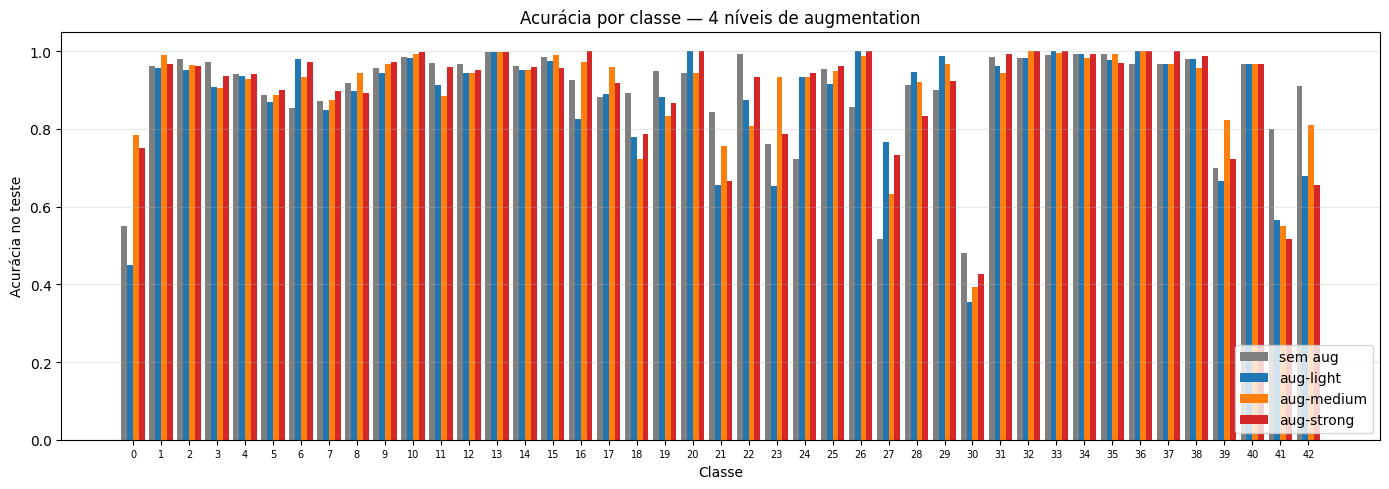

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(NUM_CLASSES)
width = 0.21
for i, tag in enumerate(("sem_aug", "aug_light", "aug_medium", "aug_strong")):
    ax.bar(x + (i - 1.5) * width, test_results[tag]["per_class_acc"], width,
           label=AUG_LABELS[tag], color=AUG_COLORS[tag])
ax.set_xlabel("Classe"); ax.set_ylabel("Acurácia no teste")
ax.set_title("Acurácia por classe — 4 níveis de augmentation")
ax.set_xticks(x); ax.set_xticklabels(x, fontsize=7)
ax.set_ylim(0, 1.05); ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figs/exp3_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

### 11.1 Quantas classes melhoraram / pioraram?

In [17]:
base_acc = test_results["sem_aug"]["per_class_acc"]

print(f"  {'Configuração':<14s} | {'melhorou':>9s} | {'piorou':>7s} | {'empate':>7s} | {'Δ média':>8s} | {'maior queda':>16s}")
print("-" * 90)
for tag in ("aug_light", "aug_medium", "aug_strong"):
    diff = test_results[tag]["per_class_acc"] - base_acc
    n_up = int((diff > 0).sum())
    n_down = int((diff < 0).sum())
    n_tie = int((diff == 0).sum())
    mean_d = float(diff.mean())
    worst_drop_idx = int(diff.argmin())
    worst_drop_val = float(diff.min())
    print(f"  {AUG_LABELS[tag]:<14s} | {n_up:>9d} | {n_down:>7d} | {n_tie:>7d} | "
          f"{mean_d:>+8.4f} | cls {worst_drop_idx:>2d} ({worst_drop_val:+.3f})")

  Configuração   |  melhorou |  piorou |  empate |  Δ média |      maior queda
------------------------------------------------------------------------------------------
  aug-light      |        11 |      27 |       5 |  -0.0188 | cls 41 (-0.233)
  aug-medium     |        21 |      17 |       5 |  +0.0028 | cls 41 (-0.250)
  aug-strong     |        23 |      16 |       4 |  +0.0017 | cls 41 (-0.283)


## 12. As 5 classes mais difíceis do baseline

In [18]:
HARD_CLASSES = [0, 30, 27, 24, 21]

header = f"  {'Classe':<8s} | " + " | ".join(f"{AUG_LABELS[t]:>12s}" for t in AUG_PIPELINES)
print(header)
print("-" * len(header))
for c in HARD_CLASSES:
    row_vals = [test_results[t]["per_class_acc"][c] for t in AUG_PIPELINES]
    row = f"  cls {c:>2d}  | " + " | ".join(f"{v:>12.4f}" for v in row_vals)
    print(row + f"  ({GTSRB_CLASSES[c]})")

print()
print("  Média sobre as 5 classes difíceis:")
for tag in AUG_PIPELINES:
    m = float(np.mean([test_results[tag]["per_class_acc"][c] for c in HARD_CLASSES]))
    print(f"    {AUG_LABELS[tag]:<14s} = {m:.4f}")

  Classe   |      sem aug |    aug-light |   aug-medium |   aug-strong
----------------------------------------------------------------------
  cls  0  |       0.5500 |       0.4500 |       0.7833 |       0.7500  (Speed limit (20km/h))
  cls 30  |       0.4800 |       0.3533 |       0.3933 |       0.4267  (Beware of ice/snow)
  cls 27  |       0.5167 |       0.7667 |       0.6333 |       0.7333  (Pedestrians)
  cls 24  |       0.7222 |       0.9333 |       0.9333 |       0.9444  (Road narrows right)
  cls 21  |       0.8444 |       0.6556 |       0.7556 |       0.6667  (Double curve)

  Média sobre as 5 classes difíceis:
    sem aug        = 0.6227
    aug-light      = 0.6318
    aug-medium     = 0.6998
    aug-strong     = 0.7042


### 12.1 Δ por classe difícil (variante − sem aug)

In [19]:
print(f"  {'cls':<5s} | {'sem aug':>8s} | {'Δ light':>9s} | {'Δ medium':>10s} | {'Δ strong':>10s}  classe")
print("-" * 90)
for c in HARD_CLASSES:
    base_v = test_results["sem_aug"]["per_class_acc"][c]
    d_l = test_results["aug_light"]["per_class_acc"][c]  - base_v
    d_m = test_results["aug_medium"]["per_class_acc"][c] - base_v
    d_s = test_results["aug_strong"]["per_class_acc"][c] - base_v
    print(f"  {c:>4d}  | {base_v:>8.4f} | {d_l:>+9.4f} | {d_m:>+10.4f} | {d_s:>+10.4f}  ({GTSRB_CLASSES[c]})")

  cls   |  sem aug |   Δ light |   Δ medium |   Δ strong  classe
------------------------------------------------------------------------------------------
     0  |   0.5500 |   -0.1000 |    +0.2333 |    +0.2000  (Speed limit (20km/h))
    30  |   0.4800 |   -0.1267 |    -0.0867 |    -0.0533  (Beware of ice/snow)
    27  |   0.5167 |   +0.2500 |    +0.1167 |    +0.2167  (Pedestrians)
    24  |   0.7222 |   +0.2111 |    +0.2111 |    +0.2222  (Road narrows right)
    21  |   0.8444 |   -0.1889 |    -0.0889 |    -0.1778  (Double curve)


### 12.2 Nova bottom-5 em cada configuração

In [20]:
for tag in AUG_PIPELINES:
    tr = test_results[tag]
    sorted_idx = np.argsort(tr["per_class_acc"])
    bottom5 = sorted_idx[:5]
    info = ", ".join(f"{c}({tr['per_class_acc'][c]:.2f})" for c in bottom5)
    print(f"  {AUG_LABELS[tag]:<14s} | bottom5: {info}")

  sem aug        | bottom5: 30(0.48), 27(0.52), 0(0.55), 39(0.70), 24(0.72)
  aug-light      | bottom5: 30(0.35), 0(0.45), 41(0.57), 23(0.65), 21(0.66)
  aug-medium     | bottom5: 30(0.39), 41(0.55), 27(0.63), 18(0.72), 21(0.76)
  aug-strong     | bottom5: 30(0.43), 41(0.52), 42(0.66), 21(0.67), 39(0.72)


## 13. Salvar predições

In [21]:
for tag, tr in test_results.items():
    out_path = f"results/predicoes_exp3_{tag}.csv"
    exp_name = f"Exp3 BN-conv+fc + SGD+momentum + {tag} | img=32 | 30 epochs"
    save_predictions(tr["y_pred"], out_path, experiment_name=exp_name)
    print(f"  {out_path}  ({len(tr['y_pred'])} predições)")

  results/predicoes_exp3_sem_aug.csv  (12630 predições)
  results/predicoes_exp3_aug_light.csv  (12630 predições)
  results/predicoes_exp3_aug_medium.csv  (12630 predições)
  results/predicoes_exp3_aug_strong.csv  (12630 predições)


## 14. Modelo final para entrega

In [ ]:
winner = max(test_results.items(), key=lambda kv: kv[1]["global_acc"])
winner_tag, winner_tr = winner

print(f"Vencedor: {AUG_LABELS[winner_tag]}")
print(f"  test global = {winner_tr['global_acc']:.4f}")
print(f"  test macro  = {winner_tr['macro_acc']:.4f}")
print(f"  val_acc     = {all_results[winner_tag]['best_val_acc']:.4f}")

save_predictions(
    winner_tr["y_pred"],
    experiment_name=f"Final | BN-conv+fc + SGD+momentum + {winner_tag} | img=32 | 30 epochs",
)

print("(lembre de trocar 'NOME2' pelo primeiro nome do seu colega antes de entregar)")

Vencedor: sem aug
  test global = 0.9346
  test macro  = 0.8960
  val_acc     = 0.9976

Arquivo de entrega salvo em: results/MATHEUS_NOME2_RESULTS.csv
(lembre de trocar 'NOME2' pelo primeiro nome do seu colega antes de entregar)
